# pyLEEM Example

This notebook shows two pyLEEM example workflows:

- X-ray photoelectron spectroscopy (XPS) analysis
    - Spectral analysis
    - Configuration file parsing and workflow analysis
    - Spectra stitching

- X-ray absorption spectroscopy (XAS) analysis
    - Image analysis
    - Drift correction and image stack analysis
    - ROI, metadata and scale bar annotation

The data used in these workflows is hosted on [pyLEEM-example](https://github.com/peterhys/pyLEEM-example).

Clone the example repository into an example directory:

```bash
git clone https://github.com/peterhys/pyLEEM-example.git example
```

Install pyLEEM:

```bash
pip install pyleem
```

Place this notebook alongside the example repository.

## XPS analysis

In XPS analysis, we first calibrate the energy scale with a known oxygen peak.

Both calibration and analysis are done using a configuration file.
The file metadata does not contain start voltage and beam energy; they are
manually added to the metadata list. The full xps_calibration.toml and xps_analysis.toml
files are stored under the XPS directory. The line ROI is stored directly in each workflow config.

In [1]:
import matplotlib.pyplot as plt
from pyleem.config import load_config
from pyleem.workflow import Workflow
from pyleem.analysis.xps import XPSAnalyzer, XPSCalibration


cali_path = "example/XPS/xps_calibration.toml"
analysis_path = "example/XPS/xps_analysis.toml"

cali_workflow = Workflow(load_config(cali_path), root="example/XPS")
cali_result = cali_workflow.run()
cali_result

{'pixel_per_ev': 165.0, 'peak_shift': np.float64(1.2574548312543872)}

Now we can run the analysis and save the result.

In [2]:
analysis_config = load_config(analysis_path).with_changes(analyzer=cali_result)
analysis_workflow = Workflow(analysis_config, root="example/XPS")
analysis_workflow.save("example/XPS/xps_analysis_updated.toml")

Here we stitch the XPS spectrum from individual segments using the built-in method `stitch_profiles`.

We then use the `fit_xps` function to fit the spectrum and display the fit result.

In [3]:
from pyleem.analysis.xps import fit_xps

xps_analyzer = analysis_workflow.analyzer

stitched_KE, stitched_profile = xps_analyzer.stitch_profiles(xps_analyzer.indices)
stitched_BE = xps_analyzer.get_metadata("Beam Energy", 0)[0] - stitched_KE


peak_constraints = {
    "O1s_1": {
        "center": {"value": 529.2, "min": 528.4, "max": 530.2},
        "sigma": {"value": 0.6, "min": 0.08, "max": 1.5},
    },
    "O1s_2": {
        "center": {"value": 531.0, "min": 530.2, "max": 531.8},
        "sigma": {"value": 0.7, "min": 0.08, "max": 1.5},
    },
}

fit_result = fit_xps(
    stitched_profile,
    stitched_BE,
    baseline=(120, 90),
    peak_constraints=peak_constraints,
    fit_range=(526, 535),
)

fit_energy = fit_result["range_abscissa"]
background = fit_result["background"]
fit_profile = fit_result["result"].eval(x=fit_energy) + background
components = fit_result["result"].eval_components(x=fit_energy)


Here we plot the raw data and the auto-stitched data.

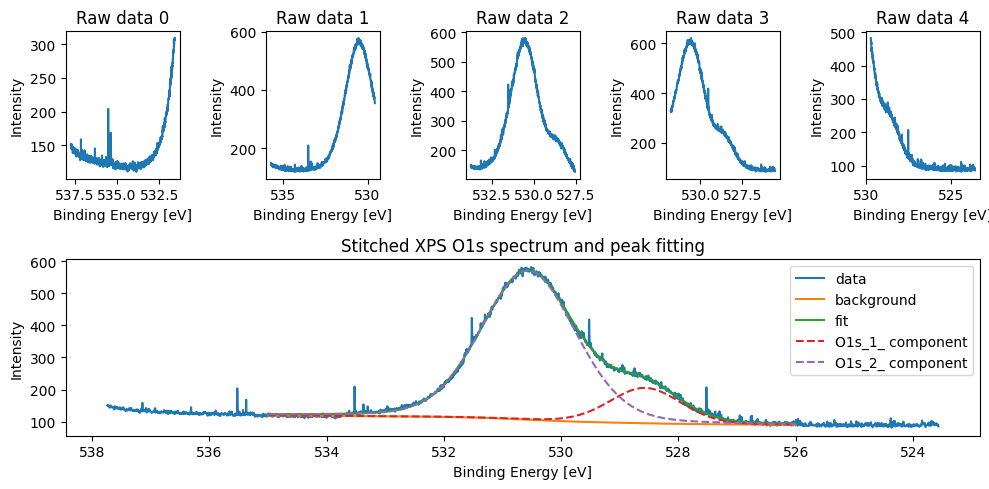

In [4]:
fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(2, 5, height_ratios=[1, 1.2])

for i, index in enumerate(xps_analyzer.indices[:5]):
    ax_raw = fig.add_subplot(gs[0, i])
    xps_analyzer.plot_profile(index, ax=ax_raw)
    ax_raw.set_title(f"Raw data {index}")
    ax_raw.invert_xaxis()

ax = fig.add_subplot(gs[1, :])
ax.plot(stitched_BE, stitched_profile, label="data")
ax.plot(fit_energy, background, label="background")
ax.plot(fit_energy, fit_profile, label="fit")

for prefix, component in components.items():
    ax.plot(fit_energy, component + background, "--", label=f"{prefix} component")
ax.invert_xaxis()
ax.set_xlabel("Binding Energy [eV]")
ax.set_ylabel("Intensity")
ax.set_title("Stitched XPS O1s spectrum and peak fitting")
ax.legend()
fig.tight_layout()
plt.show()

In [5]:
result = fit_result["result"]
print(f"XPS fit summary")
for label in fit_result["peak_labels"]:
    p = result.params
    print(
        f"{label}: "
        f"center={p[f'{label}_center'].value:.3f} [eV], "
        f"sigma={p[f'{label}_sigma'].value:.2f} [eV], "
        f"amplitude={p[f'{label}_amplitude'].value:.2f}, "
        f"fraction={p[f'{label}_fraction'].value:.2f}"
    )

XPS fit summary
O1s_1: center=528.567 [eV], sigma=0.71 [eV], amplitude=176.83, fraction=0.17
O1s_2: center=530.558 [eV], sigma=0.95 [eV], amplitude=1005.58, fraction=0.22


## XAS analysis

In this analysis, we drift-correct the image stack and analyze two different spots
on the hBN film. The beam metadata is supplied separately. The field of view (FOV) parameter
is extracted directly from the metadata.

If annotation is not needed, `XASAnalyzer` can be used directly. Because we want to
annotate the images, we create a new class with the annotation mixins.

In [6]:
from pyleem.analysis.xas import XASAnalyzer
from pyleem.annotation import ROIAnnotationMixin, MetadataTextMixin, ScaleBarMixin
from pyleem.reader import read_files
import glob

# filepath: XAS/
# beam energy: 185-210 eV, 0.1 eV/frame, 250 frames

# construct the reader
file_paths = sorted(glob.glob("example/XAS/XAS_*.dat"))
beam_metadata_list = [{"Beam Energy": (185.0 + 0.1 * i, "eV")} for i in range(251)]
xas_readers = read_files(file_paths, metadata_list=beam_metadata_list)


# construct the annotated XAS analyzer
# each analyzer can only take one ROI to keep the profile analysis consistent
# here we add a custom analyze function to analyze both ROIs
class AnnotatedXASAnalyzer(
    ROIAnnotationMixin, MetadataTextMixin, ScaleBarMixin, XASAnalyzer
):
    """XAS analyzer that can annotate metadata, scale bar, and ROI."""

    metadata_labels = {
        "Beam Energy": ("Beam Energy", ".1f", "eV"),
        "FOV": ("FOV", ".1f", "um"),
    }

    def __init__(self, readers, roi, roi_comp, onset=0):
        super().__init__(readers, roi=roi, onset=onset)
        self.roi_comp = roi_comp

    def annotate_image(self, index, ax):
        """Annotate one XAS image with all annotation mixins."""
        ax = super().annotate_image(index, ax)
        ax = self.annotate_metadata(index, ax, color="white", fontsize=9)
        ax = self.annotate_scalebar(index, ax, target_um=5, x_margin=820)
        ax = self.annotate_roi(ax, self.roi, color="teal", linewidth=2)
        ax = self.annotate_roi(ax, self.roi_comp, color="orange", linewidth=2)
        return ax

    def analyze(self):
        """Analyze the XAS image stack with two ROIs.

        Here we show two ways to get the intensity stack from ROI.
        Note processed_image is drift-corrected (if estimate_drift is called).
        """
        intensities = self.get_intensities()
        intensities_comp = [
            self.roi_comp.measure(self.get_processed_image(index)).mean
            for index in self.indices
        ]
        return intensities, intensities_comp

For analysis, we create two rectangular ROIs and a custom analyze function.

In [7]:
from pyleem.roi import RectROI
import matplotlib.pyplot as plt

left_roi = RectROI(top=420, left=360, bottom=520, right=460)
right_roi = RectROI(top=320, left=640, bottom=420, right=740)

xas_analyzer = AnnotatedXASAnalyzer(xas_readers, roi=left_roi, roi_comp=right_roi)
xas_analyzer.correct_drift(crop_size=128, max_distance=1, reference_index=160)

energy = beam_metadata_list[160]["Beam Energy"][0]
left_intensity, right_intensity = xas_analyzer.analyze()

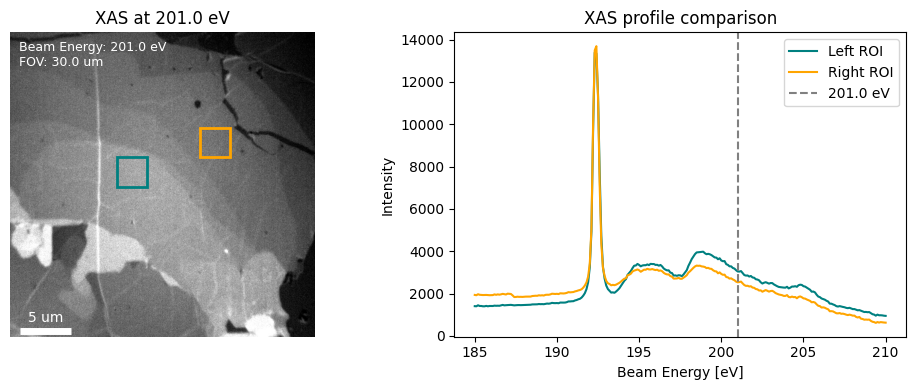

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# First subplot: the image with annotation
xas_analyzer.plot_image(160, ax=ax1, annotate=True, autolevel=True)
ax1.images[0].set_cmap("gray")
ax1.set_title(f"XAS at {energy:.1f} eV")
ax1.axis("off")

# Second subplot: intensity profiles
beam_energies = [
    xas_analyzer.get_metadata("Beam Energy", index)[0] for index in xas_analyzer.indices
]
ax2.plot(beam_energies, left_intensity, label="Left ROI", color="teal")
ax2.plot(beam_energies, right_intensity, label="Right ROI", color="orange")
ax2.set_title("XAS profile comparison")
ax2.set_xlabel("Beam Energy [eV]")
ax2.set_ylabel("Intensity")
ax2.axvline(x=energy, color="grey", linestyle="--", label="201.0 eV")
ax2.legend()

plt.tight_layout()
plt.show()